# WEMF Regions Distribution Map

This notebook creates a choropleth map of Switzerland coloured by WEMF media regions,
using district (Bezirk) level geodata from the Swiss Federal Office of Statistics (BFS).

## Required geodata

The R version uses the `bfsMaps` package, which reads local BFS geodata. In Python we use
`geopandas` to read a shapefile directly.

**You must download the BFS district shapefile before running this notebook.**

Download the *Generalisierte Gemeindegrenzen* or *Bezirke* (districts) shapefile from the
Swiss Federal Statistics Office:

- URL: https://www.bfs.admin.ch/bfs/en/home/services/geostat/swiss-federal-statistics-geodata/administrative-boundaries/generalized-boundaries-local-administrative-units.html
- Choose the **Bezirke** (districts) layer for the relevant reference year (e.g. 2022).
- Unzip the downloaded archive and note the path to the `.shp` file.

Then set `GEODATA_PATH` in the **Configuration** cell below to point to that `.shp` file.

## Configuration

In [23]:
import sys, os
from pathlib import Path
import yaml

# Resolve repo root (2 levels up from src/python/)
current_dir = Path(os.getcwd())
repo_root = current_dir.parents[1]

with open(repo_root / "config.yaml") as _f:
    _config = yaml.safe_load(_f)

# ---------------------------------------------------------------------------
# Geodata path: taken from config.yaml (paths.geodata_bezirke).
# If empty or not set, the notebook tries to download from swisstopo.
# To use a local file, set geodata_bezirke in config.yaml, e.g.:
#   geodata_bezirke: "/Users/amy/geodata/BEZIRKE_2022.shp"
# ---------------------------------------------------------------------------
_configured_path = _config.get("paths", {}).get("geodata_bezirke", "").strip()
GEODATA_PATH = _configured_path if _configured_path else None

# Name of the district-name column in the shapefile.
# Run bezirke_gdf.columns after loading to confirm.
DISTRICT_NAME_COL = "name"

# Auto-download destination (inside data_dir so it is gitignored)
_data_dir = Path(_config["paths"]["data_dir"])
_AUTO_CACHE = _data_dir / "bezirke_swisstopo.gpkg"

# swisstopo open-data URL (GeoPackage, WGS84, districts 2024)
_SWISSTOPO_URL = (
    "https://data.geo.admin.ch/ch.swisstopo.swissboundaries3d-bezirk-flaeche.fill/"
    "swissboundaries3d-bezirk-flaeche.fill_2024-01/"
    "swissboundaries3d-bezirk-flaeche.fill_2024-01_4326_5728.gpkg"
)



print(f"GEODATA_PATH     = {GEODATA_PATH}")
print(f"DISTRICT_NAME_COL = {DISTRICT_NAME_COL}")


GEODATA_PATH     = /Users/amy/MapData/2022_GEOM_TK
DISTRICT_NAME_COL = name


## Imports

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os

## WEMF Region Definitions

In [25]:
from pathlib import Path

from utils import read_clean_sheds


# Extract percentages

_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
with open(_root / "config.yaml") as f:
    config = yaml.safe_load(f)

data_dir = Path(config["paths"]["data_dir"])
data_path_file = str(data_dir / config["sheds_files"]["2025"])

sheds, meta = read_clean_sheds(data_path_file)
sheds = sheds[sheds['screen'] != 3].copy()

wemf_region_names = {
    1: "Suisse romande",
    2: "Alpen und Voralpen",
    3: "Westmittelland",
    4: "Ostmittelland",
    5: "Svizzera italiana",
}


# WEMF region metadata
region_pct = (
    sheds['region']
    .dropna()
    .astype(int)
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .rename_axis('region_id')
    .rename('pct')
)
print(region_pct)

wemf_region_labels = {
    rid: f"{name} ({region_pct.get(rid, 0):.1f}%)"
    for rid, name in wemf_region_names.items()
}

wemf_regions = {
    1: "Suisse romande",
    2: "Alpen und Voralpen",
    3: "Westmittelland",
    4: "Ostmittelland",
    5: "Svizzera italiana",
}

# Legend labels including percentages (which were extracted from the data)
#wemf_region_labels = {
#    1: "Suisse romande (22.3%)",
#    2: "Alpen und Voralpen (20.3%)",
#    3: "Westmittelland (21.5%)",
#    4: "Ostmittelland (25.5%)",
#    5: "Svizzera italiana (10.4%)",
#}

# Fill colours per region (matches the R palette)
wemf_region_colors = {
    1: "#F4A5A7",
    2: "#A8C5E2",
    3: "#A8D5A2",
    4: "#C5B3D9",
    5: "#F9D88B",
}

region_id
1    22.639115
2    20.300888
3    21.750952
4    26.046765
5     9.262280
Name: pct, dtype: float64


## District → WEMF Region Mapping

Each district name (as it appears in the BFS shapefile) is mapped to a WEMF region id.

In [26]:
# district name (BFS shapefile) → WEMF region_id
wemf_mapping = {
    # --- Region 1: Suisse romande ---
    "Cant. de Genève": 1,
    "Aigle": 1,
    "Broye-Vully": 1,
    "Gros-de-Vaud": 1,
    "Jura-Nord vaudois": 1,
    "Lausanne": 1,
    "Lavaux-Oron": 1,
    "Morges": 1,
    "Nyon": 1,
    "Ouest lausannois": 1,
    "Riviera-Pays-d'Enhaut": 1,
    "Cant. de Neuchâtel": 1,
    "Boudry": 1,
    "Val-de-Ruz": 1,
    "Val-de-Travers": 1,
    "La Chaux-de-Fonds": 1,
    "Le Locle": 1,
    "Delémont": 1,
    "Porrentruy": 1,
    "Les Franches-Montagnes": 1,
    "Jura bernois": 1,
    "La Broye": 1,
    "La Glâne": 1,
    "La Gruyère": 1,
    "La Sarine": 1,
    "See / Lac": 1,
    "Sense": 1,
    "La Veveyse": 1,
    "Monthey": 1,
    "Saint-Maurice": 1,
    "Martigny": 1,
    "Entremont": 1,
    "Conthey": 1,
    "Sion": 1,
    "Hérens": 1,
    "Sierre": 1,
    # --- Region 2: Alpen und Voralpen ---
    "Luzern-Stadt": 2,
    "Luzern-Land": 2,
    "Hochdorf": 2,
    "Sursee": 2,
    "Willisau": 2,
    "Entlebuch": 2,
    "Kt. Obwalden": 2,
    "Kt. Nidwalden": 2,
    "Thun": 2,
    "Frutigen-Niedersimmental": 2,
    "Interlaken-Oberhasli": 2,
    "Obersimmental-Saanen": 2,
    "Leuk": 2,
    "Raron": 2,
    "Visp": 2,
    "Brig": 2,
    "Goms": 2,
    "Kt. Zug": 2,
    "Kt. Uri": 2,
    "Schwyz": 2,
    "Gersau": 2,
    "Küssnacht (SZ)": 2,
    "Einsiedeln": 2,
    "March": 2,
    "Höfe": 2,
    "St. Gallen": 2,
    "Rorschach": 2,
    "Rheintal": 2,
    "Werdenberg": 2,
    "Sarganserland": 2,
    "See-Gaster": 2,
    "Toggenburg": 2,
    "Wil": 2,
    "Hinterland": 2,
    "Mittelland": 2,
    "Vorderland": 2,
    "Kt. Appenzell i.Rh.": 2,
    "Kt. Glarus": 2,
    "Imboden": 2,
    "Landquart": 2,
    "Plessur": 2,
    "Prättigau/Davos": 2,
    "Surselva": 2,
    "Albula": 2,
    "Viamala": 2,
    "Maloja": 2,
    "Engiadina Bassa/Val Müstair": 2,
    "Bernina": 2,
    # --- Region 3: Westmittelland ---
    "Kt. Basel-Stadt": 3,
    "Arlesheim": 3,
    "Liestal": 3,
    "Laufen": 3,
    "Sissach": 3,
    "Waldenburg": 3,
    "Dorneck": 3,
    "Thierstein": 3,
    "Thal": 3,
    "Solothurn": 3,
    "Lebern": 3,
    "Bucheggberg": 3,
    "Wasseramt": 3,
    "Gäu": 3,
    "Gösgen": 3,
    "Olten": 3,
    "Zofingen": 3,
    "Biel/Bienne": 3,
    "Seeland": 3,
    "Bern-Mittelland": 3,
    "Emmental": 3,
    "Oberaargau": 3,
    # --- Region 4: Ostmittelland ---
    "Aarau": 4,
    "Baden": 4,
    "Bremgarten": 4,
    "Brugg": 4,
    "Kulm": 4,
    "Laufenburg": 4,
    "Lenzburg": 4,
    "Muri": 4,
    "Rheinfelden": 4,
    "Zurzach": 4,
    "Schaffhausen": 4,
    "Stein": 4,
    "Reiat": 4,
    "Oberklettgau": 4,
    "Unterklettgau": 4,
    "Schleitheim": 4,
    "Zürich": 4,
    "Affoltern": 4,
    "Andelfingen": 4,
    "Bülach": 4,
    "Dielsdorf": 4,
    "Dietikon": 4,
    "Hinwil": 4,
    "Horgen": 4,
    "Meilen": 4,
    "Pfäffikon": 4,
    "Uster": 4,
    "Winterthur": 4,
    "Arbon": 4,
    "Frauenfeld": 4,
    "Kreuzlingen": 4,
    "Münchwilen": 4,
    "Weinfelden": 4,
    # --- Region 5: Svizzera italiana ---
    "Bellinzona": 5,
    "Blenio": 5,
    "Leventina": 5,
    "Locarno": 5,
    "Lugano": 5,
    "Mendrisio": 5,
    "Riviera": 5,
    "Vallemaggia": 5,
    "Moesa": 5,
}

## Load Geodata and Join WEMF Regions

In [27]:
# Load the BFS Bezirke shapefile / GeoPackage
from pathlib import Path

def find_bezirke_shp(base_dir: str) -> str:
    """Find the most recent Bezirke polygon shapefile under a bfsMaps-style directory."""
    base = Path(base_dir)
    # Match K4_bezk* polygon shapefiles (Gesamtfläche layer)
    candidates = sorted(base.rglob("K4bezk*gf_ch2007Poly.shp"))
    if not candidates:
        raise FileNotFoundError(f"No Bezirke shapefile found under {base_dir}")
    return str(candidates[-1])  # most recent by filename (date-sorted)

GEODATA_PATH = find_bezirke_shp(GEODATA_PATH)
print(f"Resolved shapefile: {GEODATA_PATH}")
bezirke_gdf = gpd.read_file(GEODATA_PATH)

print(f"Loaded {len(bezirke_gdf)} districts")
print(f"CRS: {bezirke_gdf.crs}")
print(f"Columns: {bezirke_gdf.columns.tolist()}")
print(bezirke_gdf[[DISTRICT_NAME_COL, "geometry"]].head())


Resolved shapefile: /Users/amy/MapData/2022_GEOM_TK/01_INST/Gesamtfläche_gf/k4_bezk20180101_gf/K4bezk20180101gf_ch2007Poly.shp
Loaded 143 districts
CRS: EPSG:2056
Columns: ['id', 'name', 'geometry']
          name                                           geometry
0    Affoltern  POLYGON ((2680802 1237767, 2680610 1236347, 26...
1  Andelfingen  POLYGON ((2697535 1270182, 2697224 1269712, 26...
2       Bülach  POLYGON ((2682972 1260247, 2681711 1261317, 26...
3    Dielsdorf  POLYGON ((2672593 1265176, 2672351 1265875, 26...
4       Hinwil  POLYGON ((2707125 1246997, 2709122 1245585, 27...


In [28]:
# Map district name → region_id and join onto the GeoDataFrame
mapping_series = pd.Series(wemf_mapping, name="region_id")
mapping_df = mapping_series.reset_index().rename(columns={"index": DISTRICT_NAME_COL})

bezirke_wemf = bezirke_gdf.merge(mapping_df, on=DISTRICT_NAME_COL, how="left")

# Report unmatched districts (helps debug name mismatches between shapefile and mapping)
unmatched = bezirke_wemf[bezirke_wemf["region_id"].isna()][DISTRICT_NAME_COL].sort_values()
if len(unmatched) > 0:
    print("Unmatched districts (check spelling against shapefile column values):")
    for name in unmatched:
        print(f"  {repr(name)}")
else:
    print("All districts matched successfully.")

print("\nRegion distribution:")
print(bezirke_wemf["region_id"].value_counts(dropna=False).sort_index())

All districts matched successfully.

Region distribution:
region_id
1    31
2    48
3    22
4    33
5     9
Name: count, dtype: int64


## Create Choropleth Map

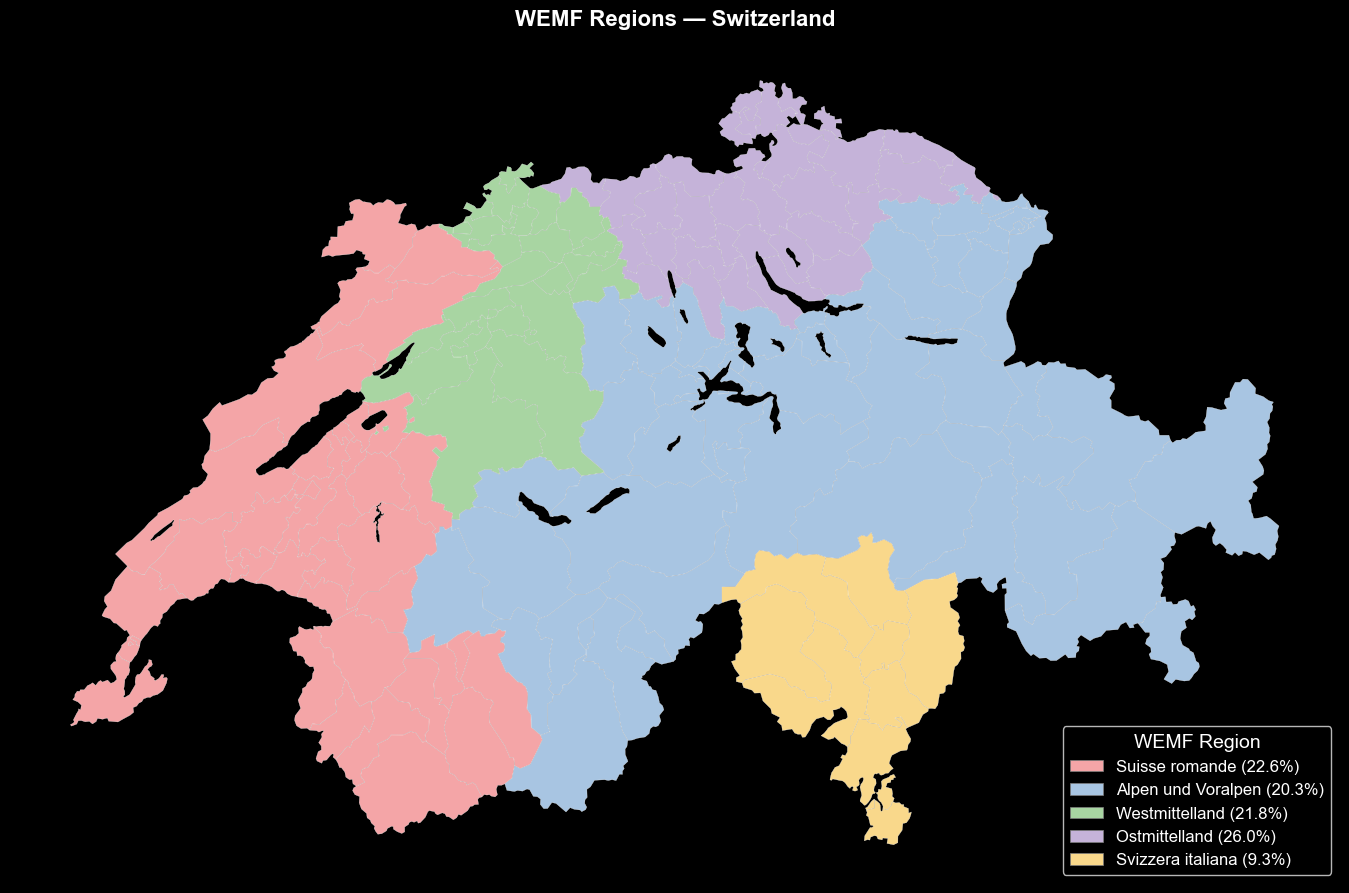

In [29]:
def create_wemf_map(bezirke_wemf, region_colors, region_labels, district_name_col):
    """Plot a choropleth map of Switzerland coloured by WEMF region."""

    fig, ax = plt.subplots(1, 1, figsize=(14, 9))

    # Assign fill colour; unmatched districts get a neutral grey
    fill_colors = bezirke_wemf["region_id"].map(
        lambda rid: region_colors.get(rid, "#CCCCCC") if pd.notna(rid) else "#CCCCCC"
    )

    bezirke_wemf.plot(
        ax=ax,
        color=fill_colors,
        edgecolor="white",
        linewidth=0.2,
    )

    # Build legend patches
    legend_handles = [
        mpatches.Patch(facecolor=region_colors[rid], edgecolor="grey", linewidth=0.5, label=label)
        for rid, label in region_labels.items()
    ]
    # Add a patch for unmatched districts if any exist
    if bezirke_wemf["region_id"].isna().any():
        legend_handles.append(
            mpatches.Patch(facecolor="#CCCCCC", edgecolor="grey", linewidth=0.5, label="Unmatched")
        )

    ax.legend(
        handles=legend_handles,
        title="WEMF Region",
        title_fontsize=14,
        fontsize=12,
        loc="lower right",
        frameon=True,
        framealpha=0.9,
    )

    ax.set_axis_off()
    ax.set_title("WEMF Regions — Switzerland", fontsize=16, fontweight="bold", pad=12)
    plt.tight_layout()
    return fig, ax


fig, ax = create_wemf_map(
    bezirke_wemf=bezirke_wemf,
    region_colors=wemf_region_colors,
    region_labels=wemf_region_labels,
    district_name_col=DISTRICT_NAME_COL,
)
plt.show()

## Save Plot

In [30]:
output_path = os.path.join(os.getcwd(), "wemf_map_regions.png")
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Plot saved to: {output_path}")

Plot saved to: /Users/amy/tmp/repos/sheds_data_scripts/src/python/wemf_map_regions.png
